# Movie Recommendation System
**Internship Project** | Collaborative Filtering with Cosine Similarity

This notebook builds a movie recommendation engine using item-item collaborative filtering.
It includes preprocessing, normalization, similarity computation, evaluation metrics, and interactive widgets.

## import Libraries

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'jinja2', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('muted')

def safe_display(df, gradient_col=None, cmap='Greens', fmt=None):
    try:
        import jinja2  # noqa
        styler = df.style.hide(axis='index')
        if gradient_col and gradient_col in df.columns:
            styler = styler.background_gradient(subset=[gradient_col], cmap=cmap)
        if fmt:
            styler = styler.format(fmt)
        display(styler)
    except Exception:
        display(df.reset_index(drop=True))

## Load & Explore Data

In [2]:
movies  = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

print('Dataset Overview')
print(f'  Movies : {movies.shape[0]:,} rows x {movies.shape[1]} cols')
print(f'  Ratings: {ratings.shape[0]:,} rows x {ratings.shape[1]} cols')
print(f'  Users  : {ratings["userId"].nunique():,}')
print(f'  Rating range: {ratings["rating"].min()} to {ratings["rating"].max()}')
movies.head()

Dataset Overview
  Movies : 62,423 rows x 3 cols
  Ratings: 25,000,095 rows x 4 cols
  Users  : 162,541
  Rating range: 0.5 to 5.0


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


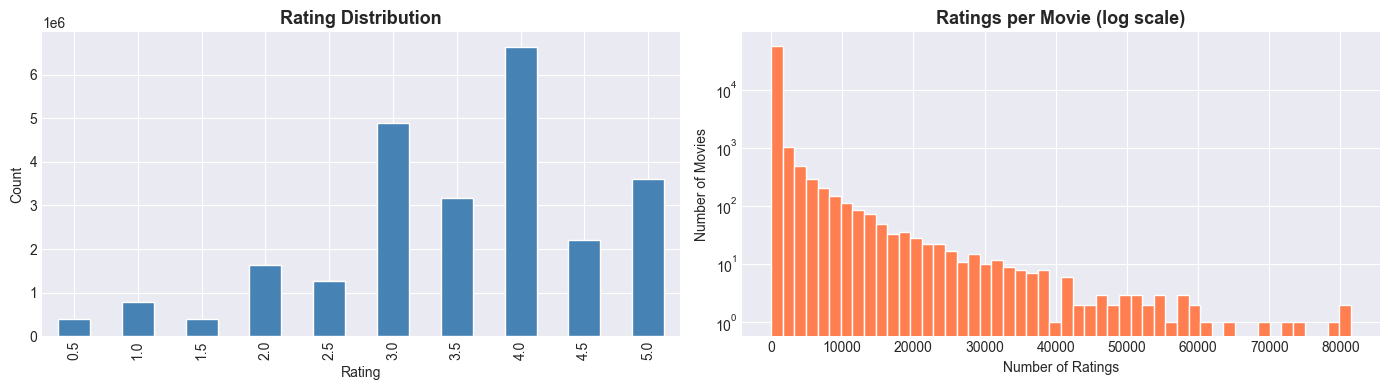

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings_per_movie = ratings.groupby('movieId')['rating'].count()
axes[1].hist(ratings_per_movie, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per Movie (log scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Movies')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing & Feature Engineering

In [5]:
df = pd.merge(ratings, movies, on='movieId')
print(f'Merged shape: {df.shape}')
df.head()

Merged shape: (25000095, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


In [6]:
top_movies = df.groupby('title')['rating'].count().nlargest(500).index
df_top = df[df['title'].isin(top_movies)]

ratings_matrix_raw = df_top.pivot_table(index='title', columns='userId', values='rating')

ratings_matrix = ratings_matrix_raw.subtract(ratings_matrix_raw.mean(axis=1), axis=0).fillna(0)

print(f'Ratings matrix shape: {ratings_matrix.shape}')
sparsity = (ratings_matrix == 0).sum().sum() / ratings_matrix.size
print(f'Matrix sparsity    : {sparsity:.1%}')
ratings_matrix.head()

Ratings matrix shape: (500, 161913)
Matrix sparsity    : 86.5%


userId,1,2,3,4,5,6,7,8,9,10,...,162532,162533,162534,162535,162536,162537,162538,162539,162540,162541
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer (2009),0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.00000,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.774656,0.0,0.0,0.00000
10 Things I Hate About You (1999),0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.00000,-0.533078,...,0.0,-1.033078,0.000000,0.0,0.0,0.0,0.966922,0.0,0.0,0.00000
12 Angry Men (1957),0.0,0.0,0.000000,0.00000,0.0,0.756986,0.0,-0.243014,0.00000,0.000000,...,0.0,0.000000,0.256986,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000
2001: A Space Odyssey (1968),0.0,0.0,1.018650,0.01865,0.0,0.018650,0.0,1.018650,-0.98135,0.518650,...,0.0,0.000000,1.018650,0.0,0.0,0.0,0.000000,0.0,0.0,-0.98135
28 Days Later (2002),0.0,0.0,-0.755558,0.00000,0.0,0.000000,0.0,0.000000,0.00000,0.744442,...,0.0,-0.255558,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000


## Compute Cosine Similarity

Similarity matrix shape: (500, 500)


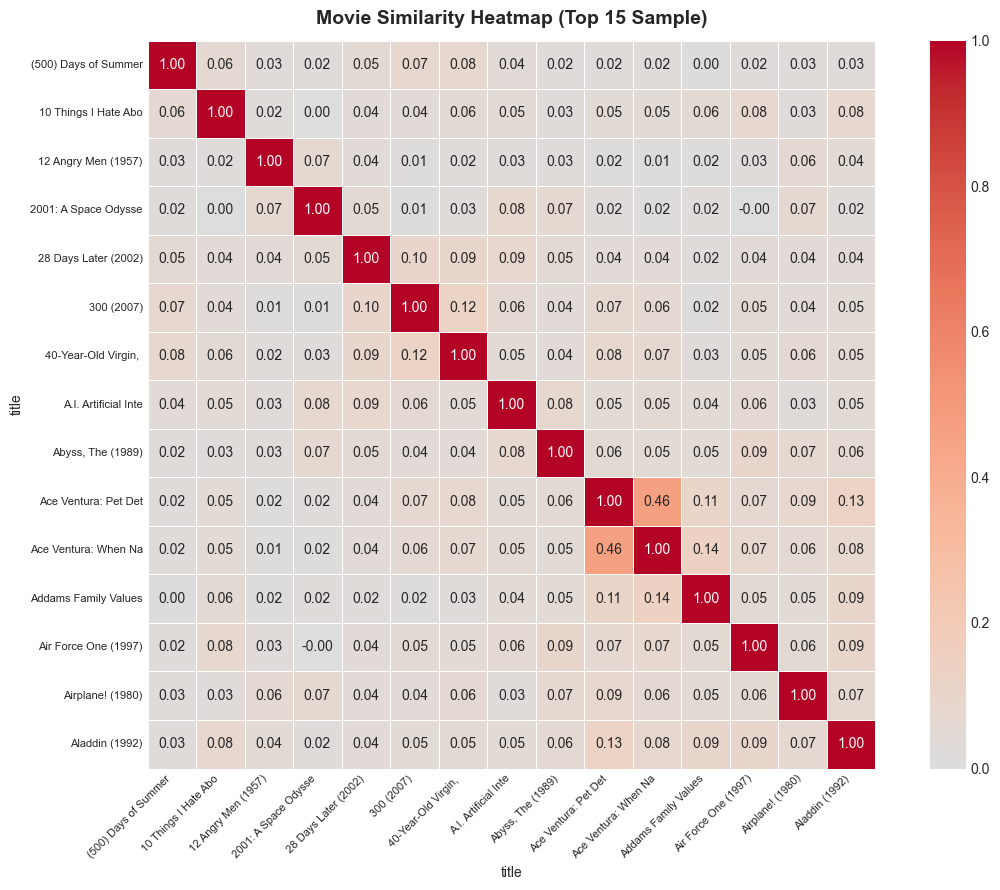

In [7]:
similarity_matrix = cosine_similarity(ratings_matrix)
sim_df = pd.DataFrame(similarity_matrix, index=ratings_matrix.index, columns=ratings_matrix.index)
print(f'Similarity matrix shape: {sim_df.shape}')

# Heatmap of a subset
sample_titles = ratings_matrix.index[:15].tolist()
plt.figure(figsize=(12, 9))
sns.heatmap(
    sim_df.loc[sample_titles, sample_titles],
    cmap='coolwarm', center=0, annot=True, fmt='.2f',
    linewidths=0.5, square=True,
    xticklabels=[t[:20] for t in sample_titles],
    yticklabels=[t[:20] for t in sample_titles]
)
plt.title('Movie Similarity Heatmap (Top 15 Sample)', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Recommendation Functions

In [8]:
def search_movies(query):
    """Fuzzy title search — returns all matches containing the query."""
    q = query.strip().lower()
    return [t for t in sim_df.index if q in t.lower()]


def recommend_movies(movie_title, top_n=10):
    """Return top-N similar movies with similarity scores and genres."""
    if movie_title not in sim_df.index:
        matches = search_movies(movie_title)
        hint = f' Did you mean: {matches[:5]}' if matches else ''
        return None, f'Movie not found in dataset.{hint}'

    recs = (
        sim_df[movie_title]
        .sort_values(ascending=False)
        .drop(movie_title)
        .head(top_n)
        .reset_index()
    )
    recs.columns = ['Movie Title', 'Similarity Score']
    recs['Similarity Score'] = recs['Similarity Score'].round(4)
    recs = recs.merge(
        movies[['title', 'genres']].rename(columns={'title': 'Movie Title'}),
        on='Movie Title', how='left'
    )
    return recs, None


def plot_recommendations(movie_title, top_n=10):
    recs, err = recommend_movies(movie_title, top_n)
    if err:
        print(f'Warning: {err}')
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(recs)))
    bars = ax.barh(recs['Movie Title'][::-1], recs['Similarity Score'][::-1],
                   color=colors[::-1], edgecolor='white')
    for bar, score in zip(bars, recs['Similarity Score'][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{score:.3f}', va='center', fontsize=8)
    ax.set_title(f'Top {top_n} Recommendations for "{movie_title}"',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_xlim(0, recs['Similarity Score'].max() * 1.2)
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.savefig('recommendations.png', dpi=150, bbox_inches='tight')
    plt.show()



## Evaluation — RMSE, MAE & Precision@K

In [9]:
train_data, test_data = train_test_split(df_top, test_size=0.2, random_state=42)

train_matrix_raw = train_data.pivot_table(index='title', columns='userId', values='rating')
train_matrix = train_matrix_raw.subtract(train_matrix_raw.mean(axis=1), axis=0).fillna(0)

train_sim = cosine_similarity(train_matrix)
train_sim_df = pd.DataFrame(train_sim, index=train_matrix.index, columns=train_matrix.index)

print(f'Train: {len(train_data):,} | Test: {len(test_data):,}')


def predict_rating(user_id, movie_title, sim_eval, mat_raw, k=20):
    if movie_title not in sim_eval.index or user_id not in mat_raw.columns:
        return np.nan
    similar = sim_eval[movie_title].drop(movie_title).nlargest(k)
    rated = mat_raw.loc[
        similar.index[similar.index.isin(mat_raw.index)], user_id
    ].dropna()
    if rated.empty:
        return np.nan
    weights = similar.loc[rated.index]
    return np.dot(rated, weights) / weights.sum() if weights.sum() != 0 else np.nan


test_sample = test_data.sample(min(500, len(test_data)), random_state=42)
preds, actuals = [], []
for _, row in test_sample.iterrows():
    pred = predict_rating(row['userId'], row['title'], train_sim_df, train_matrix_raw)
    if not np.isnan(pred):
        preds.append(pred); actuals.append(row['rating'])

if preds:
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = np.mean(np.abs(np.array(actuals) - np.array(preds)))
    print(f'\nEvaluation Results (n={len(preds)} predictions)')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')

Train: 8,755,800 | Test: 2,188,951

Evaluation Results (n=485 predictions)
  RMSE : 0.8570
  MAE  : 0.6456


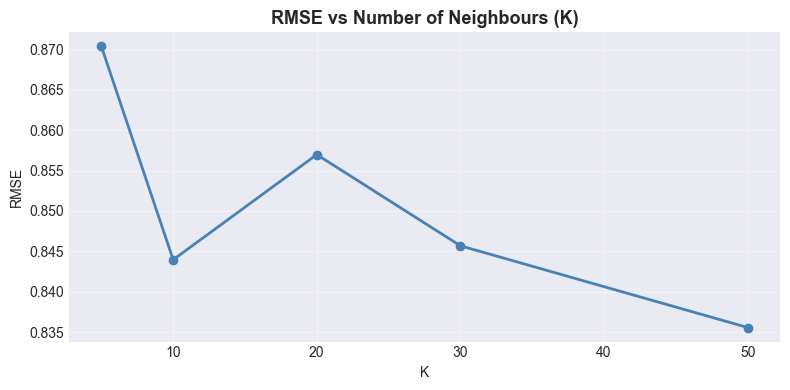

Precision@10 : 0.0611  (avg over 95 users)


In [10]:
k_values  = [5, 10, 20, 30, 50]
rmse_vals = []
for k in k_values:
    p2, a2 = [], []
    for _, row in test_sample.iterrows():
        pred = predict_rating(row['userId'], row['title'], train_sim_df, train_matrix_raw, k=k)
        if not np.isnan(pred):
            p2.append(pred); a2.append(row['rating'])
    rmse_vals.append(np.sqrt(mean_squared_error(a2, p2)) if p2 else np.nan)

plt.figure(figsize=(8, 4))
plt.plot(k_values, rmse_vals, marker='o', linewidth=2, color='steelblue')
plt.title('RMSE vs Number of Neighbours (K)', fontsize=13, fontweight='bold')
plt.xlabel('K'); plt.ylabel('RMSE')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('rmse_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision@K
def precision_at_k(user_id, k=10, threshold=4.0):
    liked = test_data[
        (test_data['userId'] == user_id) & (test_data['rating'] >= threshold)
    ]['title'].tolist()
    if not liked or liked[0] not in sim_df.index:
        return np.nan
    recs, _ = recommend_movies(liked[0], top_n=k)
    if recs is None:
        return np.nan
    return sum(1 for t in recs['Movie Title'] if t in liked) / k

sample_users = test_data['userId'].drop_duplicates().sample(min(100, test_data['userId'].nunique()), random_state=42)
precs = [p for p in (precision_at_k(u) for u in sample_users) if not np.isnan(p)]
if precs:
    print(f'Precision@10 : {np.mean(precs):.4f}  (avg over {len(precs)} users)')

## Quick Demo — Single Movie

Sample movie: "(500) Days of Summer (2009)"



,Movie Title,Similarity Score,genres
0,Juno (2007),0.1485,Comedy|Drama|Romance
1,"Social Network, The (2010)",0.1270,Drama
2,Slumdog Millionaire (2008),0.1197,Crime|Drama|Romance
3,Little Miss Sunshine (2006),0.1175,Adventure|Comedy|Drama
4,Black Swan (2010),0.1157,Drama|Thriller
5,Garden State (2004),0.1152,Comedy|Drama|Romance
6,Eternal Sunshine of the Spotless Mind (2004),0.1145,Drama|Romance|Sci-Fi
7,Superbad (2007),0.1105,Comedy
8,Inception (2010),0.1044,Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
9,Zombieland (2009),0.1012,Action|Comedy|Horror


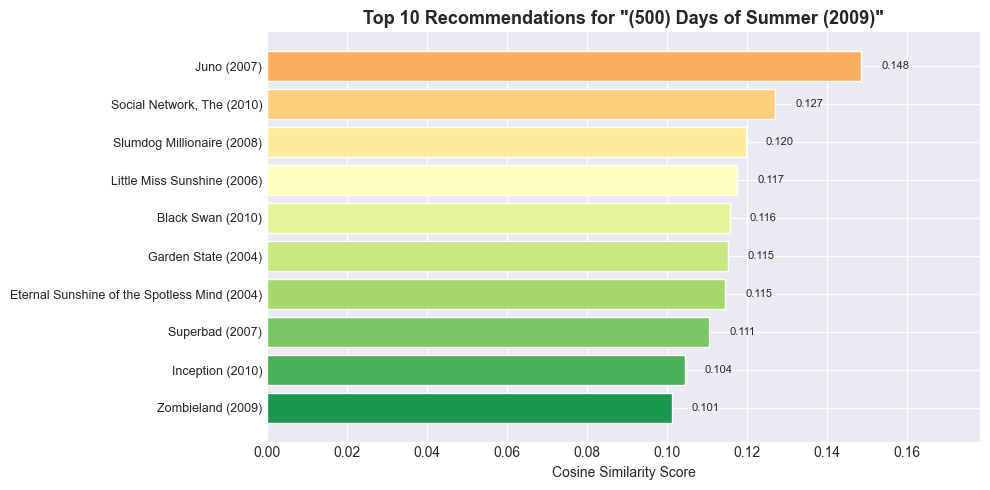

In [11]:
sample_movie = ratings_matrix.index[0]
print(f'Sample movie: "{sample_movie}"\n')
recs, err = recommend_movies(sample_movie, top_n=10)
if err:
    print(err)
else:
    safe_display(recs, gradient_col='Similarity Score', cmap='Greens')
    plot_recommendations(sample_movie, top_n=10)

## Interactive Movie Search Widget

In [12]:
title_input = widgets.Text(
    placeholder='e.g. Toy Story (1995)',
    description='Movie:',
    layout=widgets.Layout(width='400px')
)
topn_slider = widgets.IntSlider(
    value=10, min=3, max=20, step=1,
    description='Top N:',
    layout=widgets.Layout(width='380px'),
    style={'description_width': 'initial'}
)
search_btn    = widgets.Button(description='Search Titles',     button_style='info',    layout=widgets.Layout(width='150px'))
recommend_btn = widgets.Button(description='Get Recommendations', button_style='success', layout=widgets.Layout(width='200px'))
clear_btn     = widgets.Button(description='Clear',             button_style='warning', layout=widgets.Layout(width='90px'))
search_results = widgets.Select(
    options=[], description='Matches:',
    layout=widgets.Layout(width='400px', height='130px')
)
output = widgets.Output()

def on_search(b):
    q = title_input.value.strip()
    if not q: return
    matches = search_movies(q)
    search_results.options = matches if matches else ['No matches found']
    if matches: search_results.value = matches[0]

def on_recommend(b):
    movie = (search_results.value
             if search_results.value and search_results.value != 'No matches found'
             else title_input.value.strip())
    if not movie:
        with output:
            clear_output(); print('Please enter or select a movie first.')
        return
    with output:
        clear_output(wait=True)
        print(f'Finding recommendations for "{movie}"...')
        recs, err = recommend_movies(movie, top_n=topn_slider.value)
        clear_output(wait=True)
        if err:
            print(f'Warning: {err}')
        else:
            print(f'Top {topn_slider.value} recommendations for: "{movie}"\n')
            safe_display(recs, gradient_col='Similarity Score', cmap='Greens',
                         fmt={'Similarity Score': '{:.4f}'})
            plot_recommendations(movie, top_n=topn_slider.value)

def on_clear(b):
    title_input.value = ''
    search_results.options = []
    with output: clear_output()

search_btn.on_click(on_search)
recommend_btn.on_click(on_recommend)
clear_btn.on_click(on_clear)

ui = widgets.VBox([
    widgets.HTML('<h3 style="color:#2c7bb6">Movie Recommendation System</h3>'),
    widgets.HBox([title_input, search_btn]),
    search_results,
    topn_slider,
    widgets.HBox([recommend_btn, clear_btn]),
    output
], layout=widgets.Layout(padding='12px', border='1px solid #ddd'))
display(ui)

## Personalised User Recommendations Widget

In [13]:
def get_user_top_movies(user_id, n=5):
    return (df_top[df_top['userId'] == user_id]
            .sort_values('rating', ascending=False)[['title', 'rating']]
            .head(n))


def recommend_for_user(user_id, top_n=10):
    top_rated = get_user_top_movies(user_id, n=3)
    if top_rated.empty:
        return None, f'User {user_id} not found or has no ratings.'
    already_seen = set(df_top[df_top['userId'] == user_id]['title'])
    scores = {}
    for movie in top_rated['title']:
        recs, _ = recommend_movies(movie, top_n=top_n * 2)
        if recs is not None:
            for _, row in recs.iterrows():
                t = row['Movie Title']
                if t not in already_seen:
                    scores[t] = scores.get(t, 0) + row['Similarity Score']
    if not scores:
        return None, 'Could not generate recommendations.'
    result = (pd.DataFrame(list(scores.items()), columns=['Movie Title', 'Aggregated Score'])
              .sort_values('Aggregated Score', ascending=False)
              .head(top_n)
              .reset_index(drop=True))
    result['Aggregated Score'] = result['Aggregated Score'].round(4)
    return result, None


valid_users = sorted(df_top['userId'].unique().tolist())
user_id_widget = widgets.BoundedIntText(
    value=valid_users[0], min=min(valid_users), max=max(valid_users),
    description='User ID:',
    layout=widgets.Layout(width='240px'),
    style={'description_width': 'initial'}
)
user_topn = widgets.IntSlider(
    value=10, min=3, max=20, step=1,
    description='Top N:',
    layout=widgets.Layout(width='360px'),
    style={'description_width': 'initial'}
)
user_btn = widgets.Button(description='Recommend for User', button_style='success', layout=widgets.Layout(width='195px'))
user_out = widgets.Output()

def on_user_recommend(b):
    uid = user_id_widget.value
    with user_out:
        clear_output(wait=True)
        print(f'Generating for User {uid}...')
        top_df = get_user_top_movies(uid, n=5)
        recs, err = recommend_for_user(uid, top_n=user_topn.value)
        clear_output(wait=True)
        if err:
            print(f'Warning: {err}')
        else:
            print(f'User {uid} — Top Rated Movies:')
            safe_display(top_df)
            print(f'\nMovies Recommended (not yet seen by User {uid}):')
            safe_display(recs, gradient_col='Aggregated Score', cmap='Blues',
                         fmt={'Aggregated Score': '{:.4f}'})
            fig, ax = plt.subplots(figsize=(10, 5))
            colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(recs)))
            ax.barh(recs['Movie Title'][::-1], recs['Aggregated Score'][::-1], color=colors[::-1], edgecolor='white')
            ax.set_title(f'Top Recommendations for User {uid}', fontsize=13, fontweight='bold')
            ax.set_xlabel('Aggregated Similarity Score')
            ax.tick_params(axis='y', labelsize=9)
            plt.tight_layout(); plt.show()

user_btn.on_click(on_user_recommend)
user_ui = widgets.VBox([
    widgets.HTML('<h3 style="color:#2ca02c">Personalised User Recommendations</h3>'),
    widgets.HBox([user_id_widget, user_topn]),
    user_btn, user_out
], layout=widgets.Layout(padding='12px', border='1px solid #ddd'))
display(user_ui)

## Genre Explorer Widget

In [14]:
all_genres = sorted(set(
    g for genres in movies['genres'].dropna()
    for g in genres.split('|')
    if g != '(no genres listed)'
))

genre_dd   = widgets.Dropdown(options=all_genres, description='Genre:', layout=widgets.Layout(width='260px'))
genre_topn = widgets.IntSlider(value=10, min=5, max=30, step=5, description='Top N:',
                               layout=widgets.Layout(width='340px'), style={'description_width': 'initial'})
genre_btn  = widgets.Button(description='Show Top Movies', button_style='info', layout=widgets.Layout(width='170px'))
genre_out  = widgets.Output()

def on_genre(b):
    genre = genre_dd.value
    with genre_out:
        clear_output(wait=True)
        genre_movies = df_top[df_top['genres'].str.contains(genre, na=False)]
        if genre_movies.empty:
            print(f'No movies found for genre: {genre}'); return
        top = (
            genre_movies.groupby('title')['rating']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'Avg Rating', 'count': 'Num Ratings'})
            .query('`Num Ratings` >= 20')
            .sort_values('Avg Rating', ascending=False)
            .head(genre_topn.value)
            .reset_index()
            .rename(columns={'title': 'Movie Title'})
        )
        top['Avg Rating'] = top['Avg Rating'].round(2)
        print(f'Top {genre_topn.value} "{genre}" movies (min 20 ratings):\n')
        safe_display(top, gradient_col='Avg Rating', cmap='YlOrRd')
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = plt.cm.YlOrRd(np.linspace(0.3, 0.85, len(top)))
        ax.barh(top['Movie Title'][::-1], top['Avg Rating'][::-1], color=colors[::-1], edgecolor='white')
        ax.set_title(f'Top {genre_topn.value} {genre} Movies', fontsize=13, fontweight='bold')
        ax.set_xlabel('Average Rating'); ax.set_xlim(0, 5.5)
        ax.tick_params(axis='y', labelsize=9)
        plt.tight_layout(); plt.show()

genre_btn.on_click(on_genre)
genre_ui = widgets.VBox([
    widgets.HTML('<h3 style="color:#d62728">Genre Explorer</h3>'),
    widgets.HBox([genre_dd, genre_topn]),
    genre_btn, genre_out
], layout=widgets.Layout(padding='12px', border='1px solid #ddd'))
display(genre_ui)

## Conclusion

This project demonstrates the implementation of a Movie Recommendation System using machine learning techniques. The system is designed to analyze movie data and provide personalized recommendations based on user preferences and similarities between movies. Through this project, concepts such as data preprocessing, feature extraction, recommendation algorithms, and model development were explored. The project also highlights the practical application of machine learning in building intelligent recommendation systems that can enhance user experience and support content discovery